Unisco i dati dei semestri dal 2019 al 2025 in un'unica tabella, poi unisco le tabelle con i dati finanziari e le zone; aggiungo anche la colonna per gli anni e i semestri.
Raggruppo tutto in un file csv chiamato 'Tabella_completa'.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os

files_valori=glob.glob('data/**/*VALORI*.csv', recursive=True)

lista_valori=[]
for file in files_valori:
    singoli_valori=pd.read_csv(file,sep=';',encoding='latin-1',skiprows=1)
    singoli_valori = singoli_valori.loc[:, ~singoli_valori.columns.str.contains('^Unnamed')]
    cartella_periodo=os.path.basename(os.path.dirname(file))
    anno,semestre=cartella_periodo.split('_')
    singoli_valori['Anno']=int(anno)
    singoli_valori['Semestre']=semestre #S1 o S2
    lista_valori.append(singoli_valori)

tabella_valori=pd.concat(lista_valori, ignore_index=True)

files_zone=glob.glob('data/**/*ZONE*.csv', recursive=True)

lista_zone=[]
for file in files_zone:
    singole_zone=pd.read_csv(file,sep=';',encoding='latin-1',skiprows=1)
    singole_zone = singole_zone.loc[:, ~singole_zone.columns.str.contains('^Unnamed')]
    cartella_periodo=os.path.basename(os.path.dirname(file))
    anno,semestre=cartella_periodo.split('_')
    singole_zone['Anno']=int(anno)
    singole_zone['Semestre']=semestre
    lista_zone.append(singole_zone)

tabella_zone=pd.concat(lista_zone, ignore_index=True)

tabella=pd.merge(tabella_valori,tabella_zone[["Prov", "Comune_ISTAT", "Zona", "Zona_Descr", "Fascia", "Anno", "Semestre"]], 
                 on=["Prov", "Comune_ISTAT", "Zona", "Anno", "Semestre"], how='left')
tabella.to_csv('Tabella_completa.csv',index=False)

Controllo che la tabella abbia i valori giusti, in particolare trasformo i dati di "Loc_min" e "Loc_max" in float64 (erano str).

Creo un file csv chiamato 'Tab_compatta' che contiene i dati più importanti per il progetto, togliendo quelli banali come la regione, o superflui come i codici ISTAT.

Ho anche tolto gli stati degli immobili diversi da normale (come ad esempio OTTIMO) perché troppi pochi per poterci fare delle analisi sopra.

Aggiungo anche il prezzo medio al metro quadro e rimuovo le righe con valori NaN.

In [2]:
tabella["Loc_min"]=tabella["Loc_min"].str.replace(",", ".").astype(float)
tabella["Loc_max"]=tabella["Loc_max"].str.replace(",", ".").astype(float)
tab_compatta=tabella[['Prov','Comune_descrizione','Descr_Tipologia','Stato','Compr_min','Compr_max','Anno','Semestre','Zona_Descr']]
tab_compatta=tab_compatta.dropna(subset=["Compr_min", "Compr_max"])
tipologie_residenziali = ['Abitazioni civili','Ville e Villini']#,'Abitazioni di tipo economico','Abitazioni signorili','Abitazioni tipiche dei luoghi']
tab_compatta=tab_compatta[tab_compatta['Descr_Tipologia'].isin(tipologie_residenziali)]
tab_compatta=tab_compatta[tab_compatta['Stato']=='NORMALE']
tab_compatta=tab_compatta[['Prov','Comune_descrizione','Descr_Tipologia','Compr_min','Compr_max','Anno','Semestre','Zona_Descr']]
Ordine=['Anno','Semestre','Prov','Comune_descrizione','Zona_Descr']
tab_compatta=tab_compatta[Ordine+[c for c in tab_compatta.columns if c not in Ordine]]
tab_compatta['Compr_mean']=(tab_compatta['Compr_min']+tab_compatta['Compr_max'])/2
tab_compatta=tab_compatta.dropna(axis=0,how='any')
tab_compatta.to_csv('Tab_compatta.csv',index=False)

Creao le liste che mi possono servire per i grafici successivi, e preparo già i colori per evitare che si ripetano negli stessi grafici.

In [3]:
province=sorted(tab_compatta['Prov'].unique())
Comuni_pro=['RAVENNA','BOLOGNA','RIMINI','MODENA','PARMA','FERRARA','CESENA',"FORLI`",'PIACENZA',"REGGIO NELL`EMILIA"]
comuni_RA=sorted(tab_compatta[(tab_compatta['Prov']=='RA')]['Comune_descrizione'].unique())
comRA=[c for c in comuni_RA if c not in ['CERVIA','RAVENNA']]
zoneBO=sorted(tab_compatta[(tab_compatta['Comune_descrizione']=='BOLOGNA')]['Zona_Descr'].unique())
colori_zone=[cm.hsv(x) for x in np.linspace(0, 0.9, len(zoneBO))]
coloriRA=[cm.tab20(x) for x in np.linspace(0,1,len(comuni_RA))]


In questo progetto farò vedere queste 4 analisi, le ho scelte perché ognuna aggiunge una lavorazione a quella precedente.

1. Prezzo medio comuni principali Emilia Romagna;

2. Confronto prezzo medio tra tutti i comuni di Ravenna;

3. Confronto prezzi tra le zone del comune di Bologna nel 2025 e nel 2019:

    a. Come sono cambiati i prezzi minimi;

    b. Come sono cambiati i prezzi massimi;

    c. Come sono cambiati i prezzi medi;

    e. Quanto in media sono cambiati a Bologna.

4. Confronto anno per anno prezzi medi Ravenna e Bologna, crescite assolute, crescite relative.

1. Prezzo medio cumuni principali Emilia Romagna.

Come si può vedere sono grafici molto semplici che prendono direttamente i valori dal database e che non richiedono praticamente nessuna manipolazione per avere dei risultati efficaci.

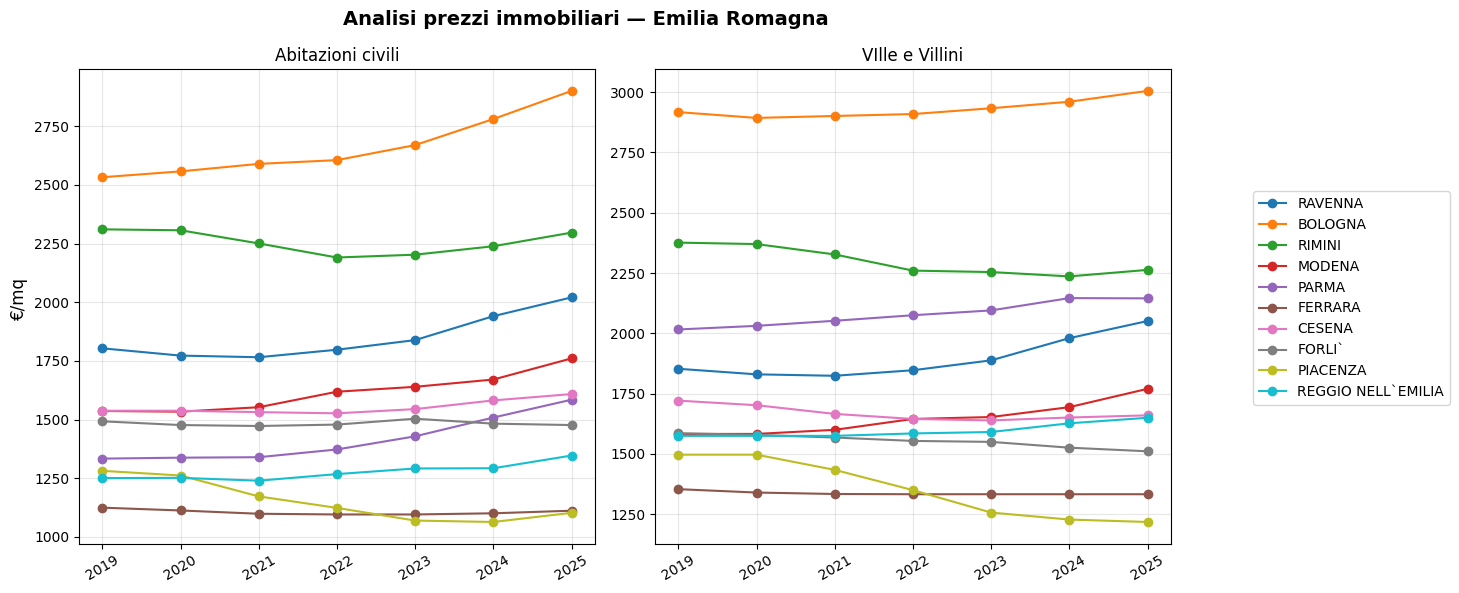

In [4]:
Comuni_pro=['RAVENNA','BOLOGNA','RIMINI','MODENA','PARMA','FERRARA','CESENA',"FORLI`",'PIACENZA',"REGGIO NELL`EMILIA"]

Prezzi_civili=tab_compatta[
    (tab_compatta['Comune_descrizione'].isin(Comuni_pro))
    & (tab_compatta['Descr_Tipologia']=='Abitazioni civili')
].groupby(["Anno",'Comune_descrizione'])["Compr_mean"].mean().round(0)

Prezzi_ville=tab_compatta[
    (tab_compatta['Comune_descrizione'].isin(Comuni_pro))
    & (tab_compatta['Descr_Tipologia']=='Ville e Villini')
].groupby(["Anno",'Comune_descrizione'])["Compr_mean"].mean().round(0)

fig, ax = plt.subplots(1,2,figsize=(12, 6))
fig.suptitle("Analisi prezzi immobiliari — Emilia Romagna", fontsize=14, fontweight="bold")

for comune in Comuni_pro:
    dati = Prezzi_civili.xs(comune, level="Comune_descrizione")
    ax[0].plot(dati.index.astype(str), dati.values, marker="o", label=comune)
    dati2=Prezzi_ville.xs(comune, level='Comune_descrizione')
    ax[1].plot(dati2.index.astype(str),dati2.values, marker='o', label=comune)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), loc="center left")
fig.supylabel("€/mq")

ax[0].set_title("Abitazioni civili")
ax[0].tick_params(axis="x", rotation=30)
ax[0].grid(True, alpha=0.3)

ax[1].set_title("VIlle e Villini")
ax[1].tick_params(axis="x", rotation=30)
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2. Confronto prezzo medio tra tutti i comuni della provincia di Ravenna.

A differenza del primo, la distanza dei prezzi tra i comuni di Ravenna e di Cervia rispetto agli altri rendeva poco leggibile il tutto, quindi li ho separati per poterli studiare meglio.

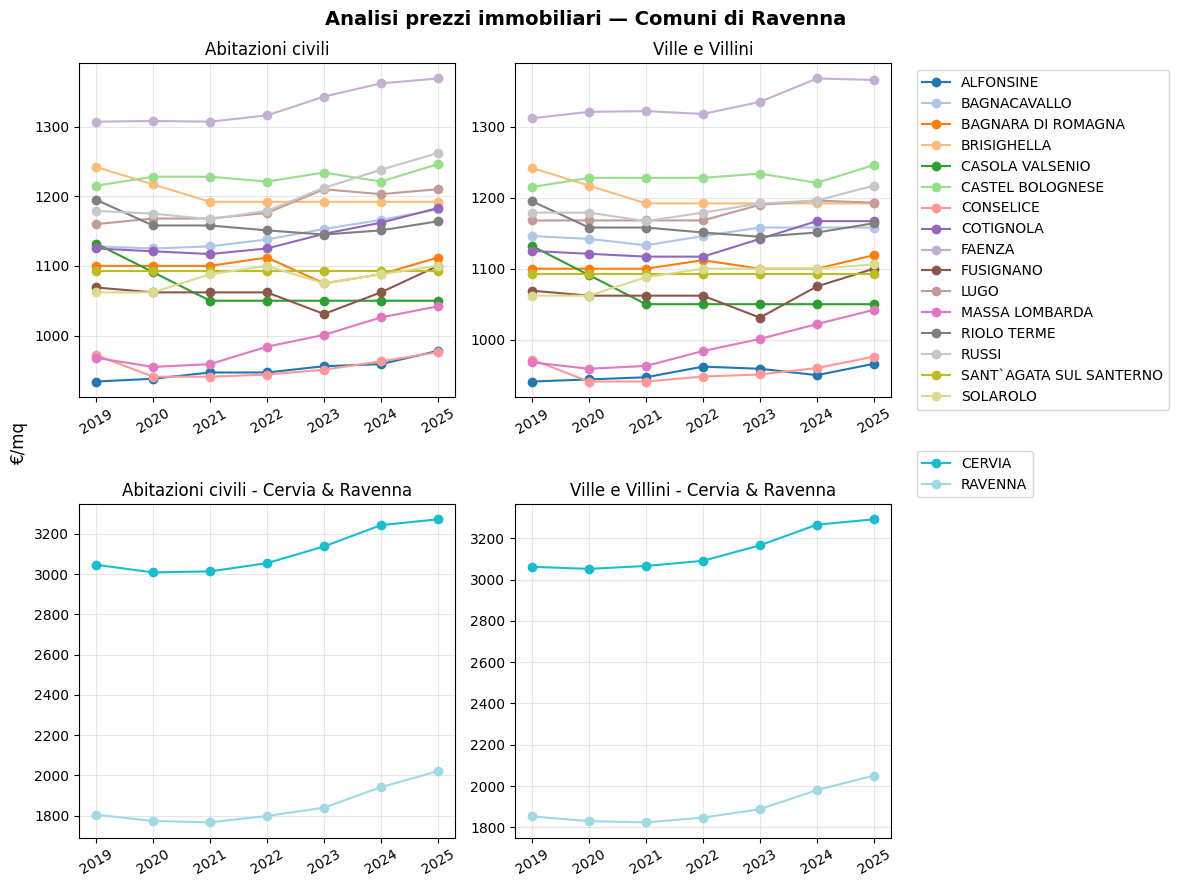

In [5]:
ravenna_normale=tab_compatta[
    (tab_compatta['Prov']=='RA')
    & (tab_compatta['Comune_descrizione'].isin(comuni_RA))
    & (tab_compatta['Descr_Tipologia']=='Abitazioni civili')
].groupby(["Anno",'Comune_descrizione'])["Compr_mean"].mean().round(0)
ravenna_normale = ravenna_normale.reset_index()

ravenna_ottimo=tab_compatta[
    (tab_compatta['Prov']=='RA')
    & (tab_compatta['Comune_descrizione'].isin(comuni_RA))
    & (tab_compatta['Descr_Tipologia']=='Ville e Villini')
].groupby(["Anno",'Comune_descrizione'])["Compr_mean"].mean().round(0)
ravenna_ottimo = ravenna_ottimo.reset_index()

fig,ax=plt.subplots(2,2,figsize=(12,9))
fig.suptitle("Analisi prezzi immobiliari — Comuni di Ravenna", fontsize=14, fontweight="bold")

for i,comune in enumerate(comRA):
    dati=ravenna_normale[ravenna_normale["Comune_descrizione"]==comune]
    ax[0,0].plot(dati["Anno"].astype(str),dati["Compr_mean"],marker="o",label=comune,color=coloriRA[i])
    dati2=ravenna_ottimo[ravenna_ottimo['Comune_descrizione']==comune]
    ax[0,1].plot(dati2['Anno'].astype(str),dati2['Compr_mean'],marker='o',label=comune,color=coloriRA[i])
for i,comune in enumerate(['CERVIA','RAVENNA']):
    dati=ravenna_normale[ravenna_normale["Comune_descrizione"]==comune]
    ax[1,0].plot(dati["Anno"].astype(str),dati["Compr_mean"],marker="o",label=comune,color=coloriRA[i+len(comRA)])
    dati2=ravenna_ottimo[ravenna_ottimo['Comune_descrizione']==comune]
    ax[1,1].plot(dati2["Anno"].astype(str),dati2["Compr_mean"],marker="o",label=comune,color=coloriRA[i+len(comRA)])

fig.supylabel("€/mq")

ax[0,0].set_title("Abitazioni civili")
ax[0,0].tick_params(axis="x", rotation=30)
ax[0,0].grid(True, alpha=0.3)

ax[0,1].set_title("Ville e Villini")
ax[0,1].tick_params(axis="x", rotation=30)
ax[0,1].grid(True, alpha=0.3)
ax[0,1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

ax[1,0].set_title("Abitazioni civili - Cervia & Ravenna")
ax[1,0].tick_params(axis="x", rotation=30)
ax[1,0].grid(True, alpha=0.3)

ax[1,1].set_title("Ville e Villini - Cervia & Ravenna")
ax[1,1].tick_params(axis="x", rotation=30)
ax[1,1].grid(True, alpha=0.3)
ax[1,1].legend(bbox_to_anchor=(1.05, 1), loc="lower left")

plt.tight_layout()
plt.show()

3. Confronto prezzi tra le zone del comune di Bologna nel 2025 e nel 2019:

    a. Come sono cambiati i prezzi minimi;

    b. Come sono cambiati i prezzi massimi;

    c. Come sono cambiati i prezzi medi;

    e. Quanto in media sono cambiati a Bologna.

Al posto di prendere direttamente i dati dal database qui espongo dei dati che ho manipolato per fare una analisi più complessa, prima ho calcolato le variazioni dei prezzi in ogni zona e poi ho aggiunto anche la media in ogni grafico.

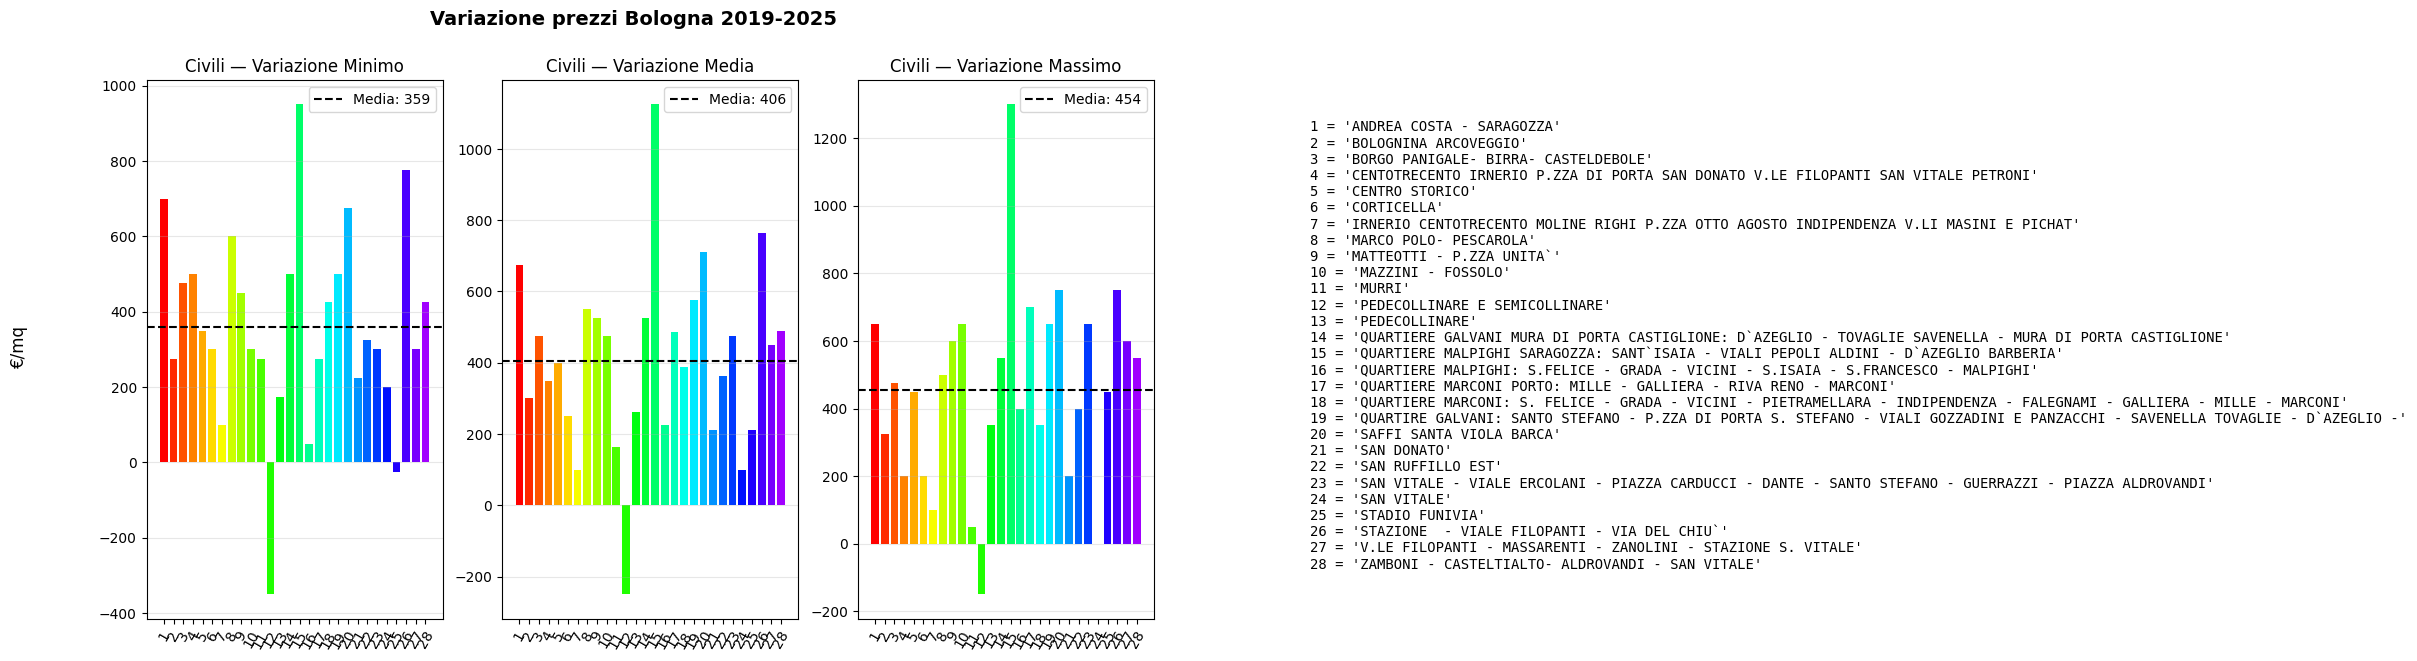

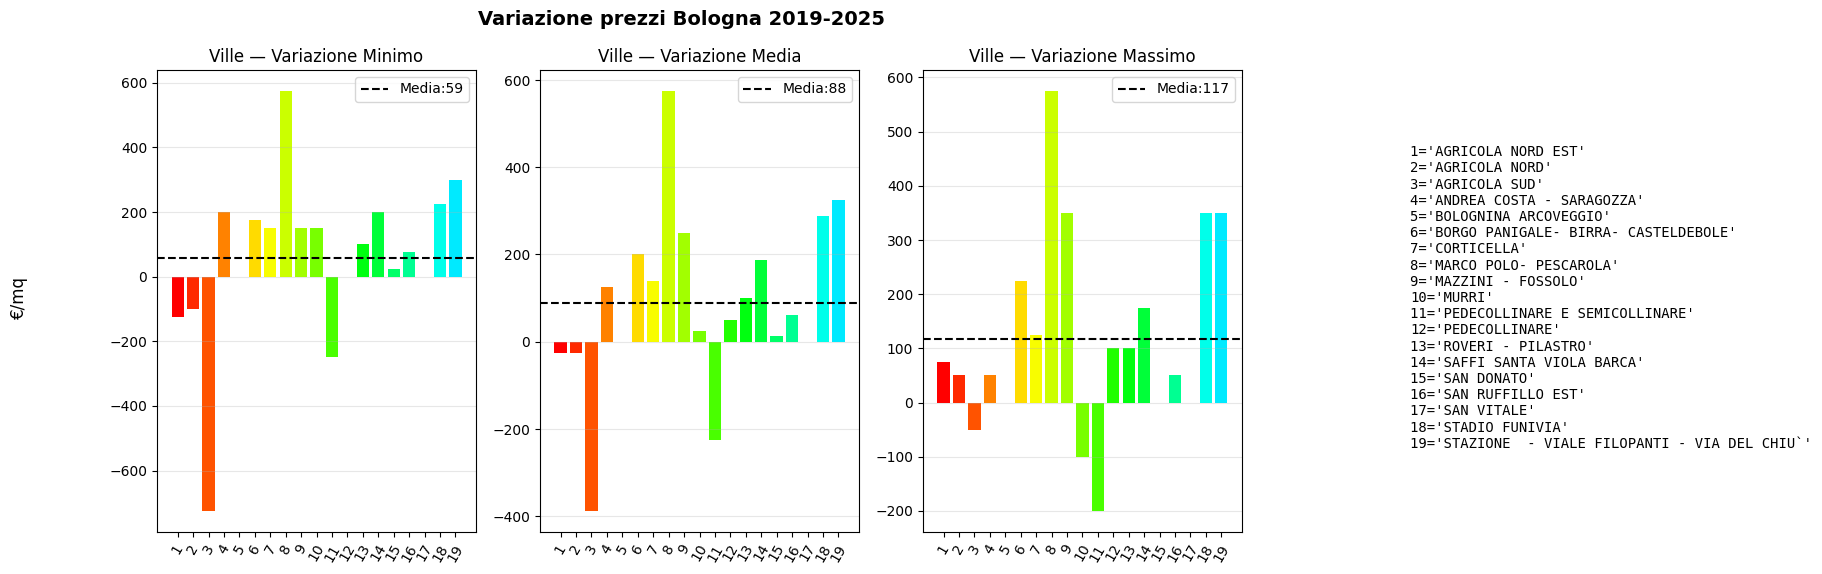

In [6]:
ZoneBO=sorted(tab_compatta[(tab_compatta['Comune_descrizione']=='BOLOGNA')]['Zona_Descr'].unique())
bologna_zone=tab_compatta[
    (tab_compatta['Comune_descrizione']=='BOLOGNA')
    & (tab_compatta['Descr_Tipologia']=='Abitazioni civili')
].groupby(["Anno","Zona_Descr"])[["Compr_min","Compr_max","Compr_mean"]].mean().round(0).reset_index()

max_2019=bologna_zone[bologna_zone["Anno"]==2019].set_index("Zona_Descr")["Compr_max"]
max_2025=bologna_zone[bologna_zone["Anno"]==2025].set_index("Zona_Descr")["Compr_max"]

min_2019=bologna_zone[bologna_zone["Anno"]==2019].set_index("Zona_Descr")["Compr_min"]
min_2025=bologna_zone[bologna_zone["Anno"]==2025].set_index("Zona_Descr")["Compr_min"]

mean_2019=bologna_zone[bologna_zone["Anno"]==2019].set_index("Zona_Descr")["Compr_mean"]
mean_2025=bologna_zone[bologna_zone["Anno"]==2025].set_index("Zona_Descr")["Compr_mean"]

civ_var_max=(max_2025-max_2019).dropna()
civ_var_min=(min_2025-min_2019).dropna()
civ_var_mean=(mean_2025-mean_2019).dropna()

civ_var_max_mean=civ_var_max.mean().round(0)
civ_var_min_mean=civ_var_min.mean().round(0)
civ_var_mean_mean=civ_var_mean.mean().round(0)

bologna_zone=tab_compatta[
    (tab_compatta['Comune_descrizione']=='BOLOGNA')
    & (tab_compatta['Descr_Tipologia']=='Ville e Villini')
].groupby(["Anno","Zona_Descr"])[["Compr_min","Compr_max","Compr_mean"]].mean().round(0).reset_index()

max_2019=bologna_zone[bologna_zone["Anno"]==2019].set_index("Zona_Descr")["Compr_max"]
max_2025=bologna_zone[bologna_zone["Anno"]==2025].set_index("Zona_Descr")["Compr_max"]

min_2019=bologna_zone[bologna_zone["Anno"]==2019].set_index("Zona_Descr")["Compr_min"]
min_2025=bologna_zone[bologna_zone["Anno"]==2025].set_index("Zona_Descr")["Compr_min"]

mean_2019=bologna_zone[bologna_zone["Anno"]==2019].set_index("Zona_Descr")["Compr_mean"]
mean_2025=bologna_zone[bologna_zone["Anno"]==2025].set_index("Zona_Descr")["Compr_mean"]

vil_var_max=(max_2025-max_2019).dropna()
vil_var_min=(min_2025-min_2019).dropna()
vil_var_mean=(mean_2025-mean_2019).dropna()

vil_var_max_mean=vil_var_max.mean().round(0)
vil_var_min_mean=vil_var_min.mean().round(0)
vil_var_mean_mean=vil_var_mean.mean().round(0)

fig,ax=plt.subplots(1,3,figsize=(13,7))
fig.suptitle("Variazione prezzi Bologna 2019-2025", fontsize=14, fontweight="bold")
fig.supylabel("€/mq")

zone_labels=civ_var_min.index.tolist()
x=range(len(zone_labels))
legenda_testo="\n".join([f"{i+1} = {nome}" for i, nome in enumerate(zone_labels)])
fig.text(1.02, 0.5, legenda_testo, ha="left", va="center", fontsize=10, family="monospace")

ax[0].bar(x, civ_var_min.values, color=colori_zone)
ax[0].set_xticks(x)
ax[0].set_xticklabels(range(1, len(zone_labels)+1))
ax[0].set_title("Civili — Variazione Minimo")
ax[0].axhline(y=civ_var_min_mean, color="black", linestyle="--", label=f"Media: {civ_var_min_mean:.0f}")
ax[0].legend()

ax[1].bar(x, civ_var_mean.values, color=colori_zone)
ax[1].set_xticks(x)
ax[1].set_xticklabels(range(1, len(zone_labels)+1))
ax[1].set_title("Civili — Variazione Media")
ax[1].axhline(y=civ_var_mean_mean, color="black", linestyle="--", label=f"Media: {civ_var_mean_mean:.0f}")
ax[1].legend()

ax[2].bar(x, civ_var_max.values, color=colori_zone)
ax[2].set_xticks(x)
ax[2].set_xticklabels(range(1, len(zone_labels)+1))
ax[2].set_title("Civili — Variazione Massimo")
ax[2].axhline(y=civ_var_max_mean,color="black",linestyle="--",label=f"Media: {civ_var_max_mean:.0f}")
ax[2].legend()

for a in ax.flat:
    a.tick_params(axis="x",rotation=60)
    a.grid(True,alpha=0.3,axis="y")

fig, ax = plt.subplots(1, 3, figsize=(14,6))
fig.suptitle("Variazione prezzi Bologna 2019-2025",fontsize=14,fontweight="bold")
fig.supylabel("€/mq")

zone_labels=vil_var_min.index.tolist()
x=range(len(zone_labels))
legenda_testo="\n".join([f"{i+1}={nome}" for i, nome in enumerate(zone_labels)])
fig.text(1.02, 0.5, legenda_testo, ha="left", va="center", fontsize=10, family="monospace")

ax[0].bar(x,vil_var_min.values,color=colori_zone)
ax[0].set_xticks(x)
ax[0].set_xticklabels(range(1, len(zone_labels)+1))
ax[0].set_title("Ville — Variazione Minimo")
ax[0].axhline(y=vil_var_min_mean,color="black",linestyle="--",label=f"Media:{vil_var_min_mean:.0f}")
ax[0].legend()

ax[1].bar(x,vil_var_mean.values,color=colori_zone)
ax[1].set_xticks(x)
ax[1].set_xticklabels(range(1, len(zone_labels)+1))
ax[1].set_title("Ville — Variazione Media")
ax[1].axhline(y=vil_var_mean_mean,color="black",linestyle="--",label=f"Media:{vil_var_mean_mean:.0f}")
ax[1].legend()

ax[2].bar(x,vil_var_max.values,color=colori_zone)
ax[2].set_xticks(x)
ax[2].set_xticklabels(range(1, len(zone_labels)+1))
ax[2].set_title("Ville — Variazione Massimo")
ax[2].axhline(y=vil_var_max_mean,color="black",linestyle="--",label=f"Media:{vil_var_max_mean:.0f}")
ax[2].legend()

for a in ax.flat:
    a.tick_params(axis="x",rotation=60)
    a.grid(True,alpha=0.3,axis="y")

plt.show()

4. Confronto anno per anno prezzi medi Ravenna e Bologna.

Infine una analisi che mischia quello che ho usato precedentemente in modo elegante.

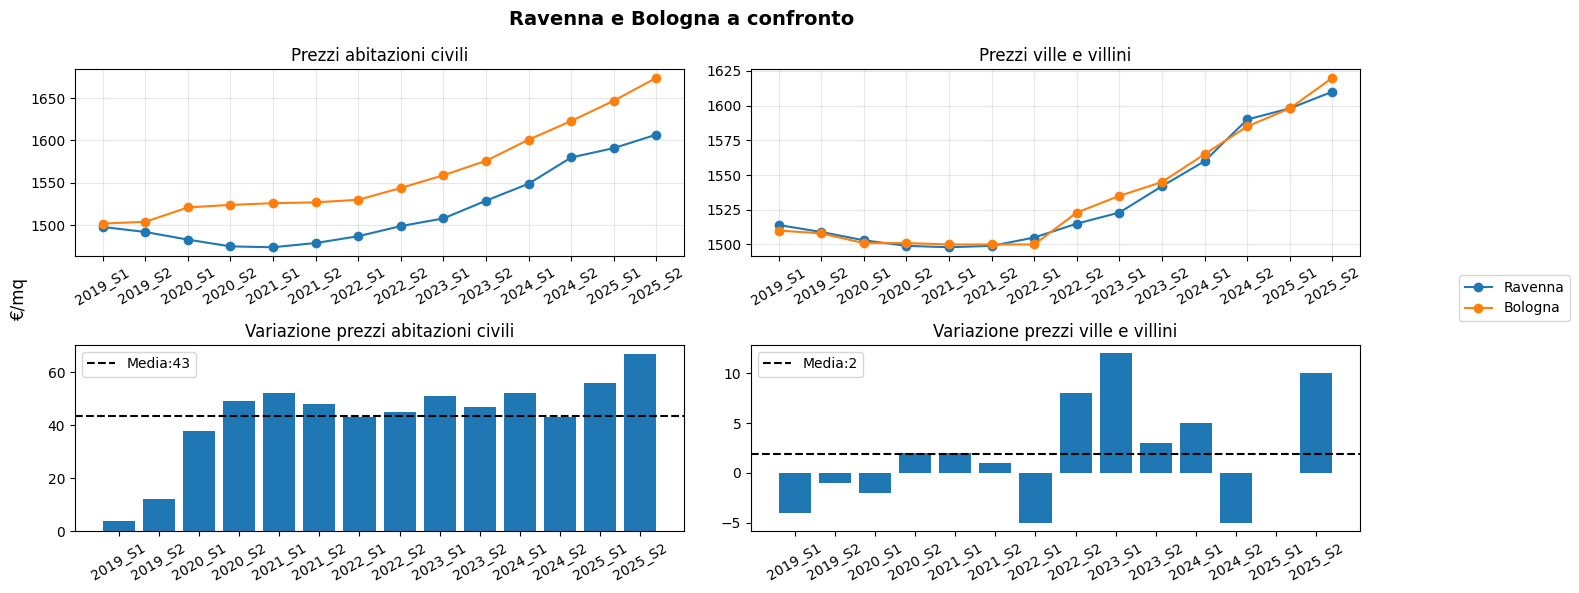

In [7]:
bologna = tab_compatta[
    (tab_compatta['Prov']=='BO')
    & (tab_compatta['Descr_Tipologia']=='Abitazioni civili')
].groupby(["Anno", "Semestre"])["Compr_mean"].mean().round(0)
ravenna= tab_compatta[
    (tab_compatta['Prov']=='RA')
    & (tab_compatta['Descr_Tipologia']=='Abitazioni civili')
].groupby(["Anno",'Semestre'])["Compr_mean"].mean().round(0)

bologna_vil=tab_compatta[
    (tab_compatta['Prov']=='BO')
    & (tab_compatta['Descr_Tipologia']=='Ville e Villini')
].groupby(["Anno", "Semestre"])["Compr_mean"].mean().round(0)
ravenna_vil= tab_compatta[
    (tab_compatta['Prov']=='RA')
    & (tab_compatta['Descr_Tipologia']=='Ville e Villini')
].groupby(["Anno",'Semestre'])["Compr_mean"].mean().round(0)

diff_civ=bologna-ravenna
diff_vil=bologna_vil-ravenna_vil
mean_civ=diff_civ.mean()
mean_vil=diff_vil.mean()

periodi = ravenna.index.map(lambda x: f"{x[0]}_{x[1]}")
x = range(len(periodi))
width = 0.35

fig, ax = plt.subplots(2,2,figsize=(14, 6))

fig.suptitle("Ravenna e Bologna a confronto", fontsize=14, fontweight="bold")

ax[0,0].plot(list(x),ravenna.values, marker="o", label="Ravenna")
ax[0,0].plot(list(x),bologna.values, marker="o", label="Bologna")
ax[0,1].plot(list(x),ravenna_vil.values, marker="o", label="Ravenna")
ax[0,1].plot(list(x),bologna_vil.values, marker="o", label="Bologna")

fig.supylabel("€/mq")
handles,labels=ax[0,0].get_legend_handles_labels()
fig.legend(handles,labels,bbox_to_anchor=(1.05, 0.5),loc="center left")
ax[0,0].set_title("Prezzi abitazioni civili")
ax[0,1].set_title("Prezzi ville e villini")
ax[0,0].set_xticks(x)
ax[0,1].set_xticks(x)
ax[0,0].set_xticklabels(periodi, rotation=30)
ax[0,1].set_xticklabels(periodi, rotation=30)
ax[0,0].grid(True, alpha=0.3)
ax[0,1].grid(True, alpha=0.3)

ax[1,0].set_title("Variazione prezzi abitazioni civili")
ax[1,1].set_title("Variazione prezzi ville e villini")
ax[1,0].bar(list(x),diff_civ.values)
ax[1,0].set_xticks(x)
ax[1,0].set_xticklabels(periodi, rotation=30)
ax[1,1].bar(list(x),diff_vil.values)
ax[1,1].set_xticks(x)
ax[1,1].set_xticklabels(periodi, rotation=30)
ax[1,0].axhline(y=mean_civ,color="black",linestyle="--",label=f"Media:{mean_civ:.0f}")
ax[1,1].axhline(y=mean_vil,color="black",linestyle="--",label=f"Media:{mean_vil:.0f}")
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()